In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
df = pd.read_csv("traffic_data_sample.csv")

In [36]:
df = df.sort_values("timestamp")

In [4]:
df.head()

,junction_id,timestamp,vehicle_count,avg_speed
0,J1,2025-01-01 06:00,62,13
1,J1,2025-01-01 06:05,172,11
2,J1,2025-01-01 06:10,104,12
3,J1,2025-01-01 06:15,113,35
4,J1,2025-01-01 06:20,92,77


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   junction_id    300 non-null    object
 1   timestamp      300 non-null    object
 2   vehicle_count  300 non-null    int64 
 3   avg_speed      300 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 9.5+ KB


In [6]:
df.describe()

,vehicle_count,avg_speed
count,300.000000,300.000000
mean,98.980000,45.366667
std,50.139867,20.087573
min,11.000000,10.000000
25%,54.750000,29.000000
50%,100.000000,45.000000
75%,142.000000,64.000000
max,180.000000,80.000000


Data Cleaning

In [7]:
df.drop_duplicates(inplace=True)

In [9]:
# Ensure non-negative vehicle counts

df = df[df['vehicle_count'] >= 0]

In [10]:
#  Filter unrealistic speeds

df = df[(df['avg_speed'] >= 0) & (df['avg_speed'] <= 120)]


In [11]:
# Convert timestamps into datetime

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.dropna(subset=['timestamp'], inplace=True)


In [44]:
df.columns

Index(['junction_id', 'timestamp', 'vehicle_count', 'avg_speed', 'hour',
       'date', 'daily_avg', 'congested', 'target', 'z_score',
       'traffic_cluster'],
      dtype='object')

In [12]:
# Extract time features

df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date


Basic Traffic Analytics (90 mins)

In [13]:
# Average vehicle count per junction

avg_per_junction = df.groupby("junction_id")["vehicle_count"].mean()


In [14]:
# Peak traffic hour

peak_hour = df.groupby("hour")["vehicle_count"].sum().idxmax()


In [15]:
# Top 3 busiest junctions

top3 = avg_per_junction.sort_values(ascending=False).head(3)

In [ ]:
# Congestion-prone low speed zones

low_speed_zones = df[df["avg_speed"] < 20]

Congestion Detection Logic (75 mins)

In [ ]:
# Calculate daily junction average

junction_daily_avg = df.groupby(["junction_id","date"])["vehicle_count"].mean().reset_index()
junction_daily_avg.rename(columns={"vehicle_count":"daily_avg"}, inplace=True)

df = df.merge(junction_daily_avg, on=["junction_id","date"])

In [23]:
print(df.columns)

Index(['junction_id', 'timestamp', 'vehicle_count', 'avg_speed', 'hour',
       'date'],
      dtype='object')


-----------------------------------------------------------------------------

In [24]:
# Solved the error adding Daily_avg

daily_avg = (
    df.groupby(["junction_id", "date"])["vehicle_count"]
    .mean()
    .reset_index()
    .rename(columns={"vehicle_count": "daily_avg"})
)


In [25]:
df = df.merge(daily_avg, on=["junction_id", "date"], how="left")


In [26]:
print(df.columns)


Index(['junction_id', 'timestamp', 'vehicle_count', 'avg_speed', 'hour',
       'date', 'daily_avg'],
      dtype='object')


-----------------------------------------------------------------------------

In [27]:
# Create congestion flag

df["congested"] = np.where(
    (df["vehicle_count"] > (1.5 * df["daily_avg"])) &
    (df["avg_speed"] < 25),
    True,
    False
)

In [28]:
# Store congestion events

congestion_events = df[df["congested"] == True]


Visualization

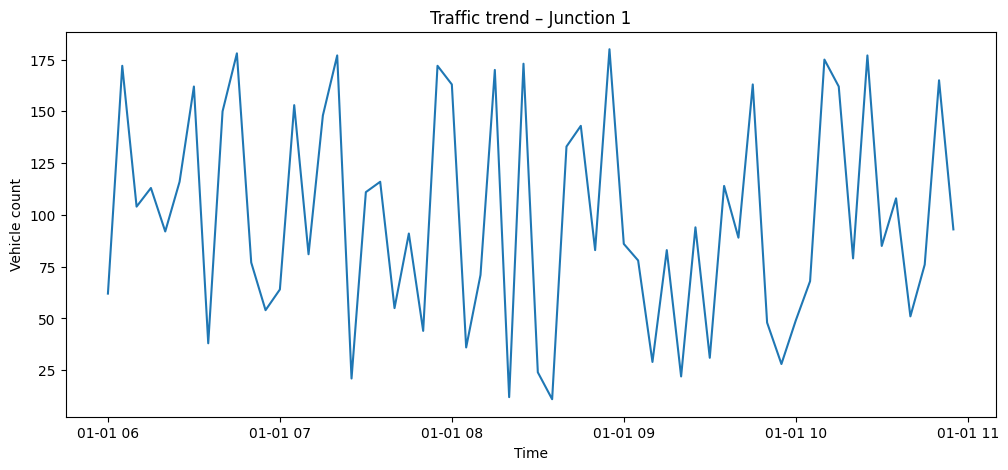

In [48]:
junction_x = df[df["junction_id"] == "J1"]   # pick any junction

plt.figure(figsize=(12,5))
plt.plot(junction_x["timestamp"], junction_x["vehicle_count"])
plt.title("Traffic trend – Junction 1")
plt.xlabel("Time")
plt.ylabel("Vehicle count")
plt.show()


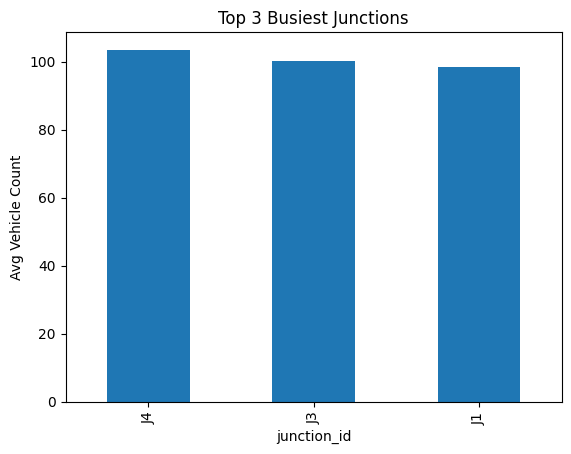

In [29]:
# Busiest junction bar chart

top3.plot(kind='bar', title="Top 3 Busiest Junctions")
plt.ylabel("Avg Vehicle Count")
plt.show()

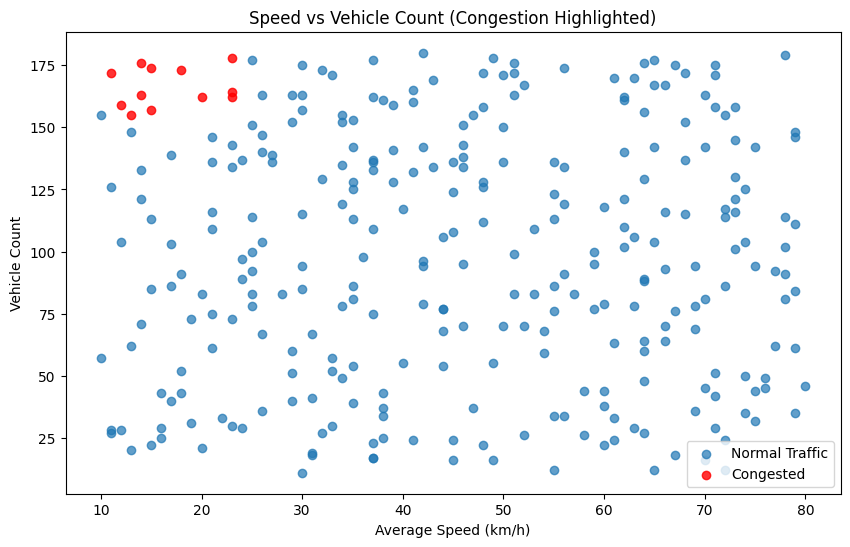

In [49]:
# Speed vs vehicle count scatter plot

plt.figure(figsize=(10,6))

# Plot non-congested points (blue)
normal = df[df["congested"] == False]
plt.scatter(normal["avg_speed"], normal["vehicle_count"],
            label="Normal Traffic", alpha=0.7)

# Plot congested points (red)
congest = df[df["congested"] == True]
plt.scatter(congest["avg_speed"], congest["vehicle_count"],
            color='red', label="Congested", alpha=0.8)

plt.title("Speed vs Vehicle Count (Congestion Highlighted)")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Vehicle Count")
plt.legend()
plt.show()



Summary Console Report 

In [31]:
print("Total Records: ", len(df))
print("Total Congestion Events: ", congestion_events.shape[0])
print("Busiest Junction: ", top3.index[0])
print("Peak Traffic Hour: ", peak_hour)


Total Records:  300
Total Congestion Events:  12
Busiest Junction:  J4
Peak Traffic Hour:  6


Traffic Prediction Model 

In [34]:
df.columns


Index(['junction_id', 'timestamp', 'vehicle_count', 'avg_speed', 'hour',
       'date', 'daily_avg', 'congested'],
      dtype='object')